# 🤸 YOLOv8 Keypoint Detection (Pose Estimation) & Multi-Object Tracking

In Notebook 02, we explored Object Detection using bounding boxes $(x, y, w, h)$ to locate objects in an image. While bounding boxes tell us *where* an object is, they don't capture the structural posture or internal landmarks of the object.

In this notebook, we extend computer vision into two critical real-world dimensions:
1. **Keypoint Detection / Pose Estimation:** Predicting specific anatomical joints (e.g. eyes, shoulders, knees, ankles) to model human body orientation.
2. **Multi-Object Tracking (MOT):** Maintaining unique, persistent identity IDs for moving objects across consecutive video frames.

### Key Learning Objectives
1. **Pose Estimation Theory:** Understanding the COCO 17-keypoint standard and regression loss.
2. **YOLOv8-Pose Inference:** Loading pre-trained YOLOv8-pose models and parsing raw keypoint tensors.
3. **Custom Skeleton Visualization:** Writing a custom Matplotlib renderer to connect joint pairs into a human skeleton map.
4. **Multi-Object Tracking:** Using ByteTRACK to maintain persistent bounding box IDs across video frames.

## 1. Setup: Libraries and Environment

We will use the `ultralytics` package for YOLOv8 models, `opencv-python` and `matplotlib` for frame processing and visualization.

In [1]:
# Install required packages
!pip install -q ultralytics opencv-python matplotlib requests pillow

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from ultralytics import YOLO

# Check for GPU acceleration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


## 2. Pose Estimation Concepts & COCO Keypoints

Human Pose Estimation localizes key landmarks on a person's body. The standard benchmark is the **COCO Keypoints Dataset**, which defines **17 spatial points**:

| Index | Landmark Name | Index | Landmark Name |
| :--- | :--- | :--- | :--- |
| 0 | Nose | 9 | Left Wrist |
| 1 / 2 | Left / Right Eye | 10 | Right Wrist |
| 3 / 4 | Left / Right Ear | 11 / 12 | Left / Right Hip |
| 5 / 6 | Left / Right Shoulder | 13 / 14 | Left / Right Knee |
| 7 / 8 | Left / Right Elbow | 15 / 16 | Left / Right Ankle |

### Output Tensor Format
For each person detected in an image, YOLOv8-pose outputs:
* **Bounding Box:** $[x_1, y_1, x_2, y_2, \text{conf}, \text{class}]$
* **Keypoints Tensor:** $[17, 3]$ matrix containing $(x, y, \text{confidence})$ for each of the 17 keypoints.

## 3. Running YOLOv8-Pose Inference

We will load `yolov8n-pose.pt` (the nano pose model), download a sample image of people exercising, and inspect the default annotation outputs.


image 1/1 /content/sample_pose.jpg: 448x640 1 person, 7.3ms
Speed: 79.6ms preprocess, 7.3ms inference, 34.9ms postprocess per image at shape (1, 3, 448, 640)


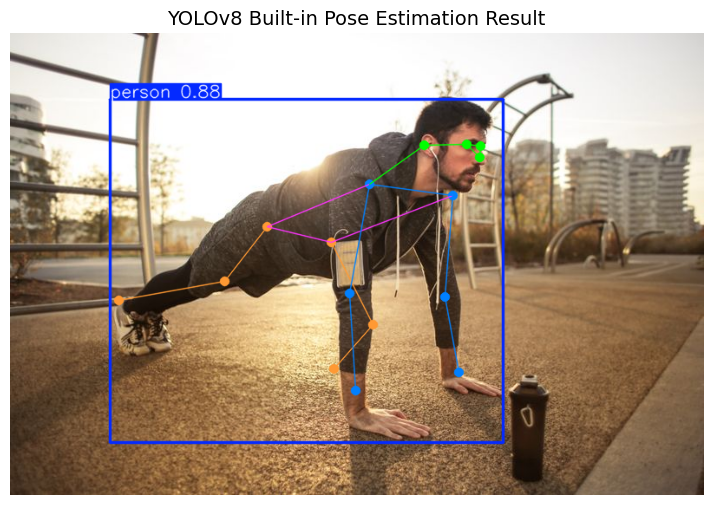

In [2]:
# 1. Load pre-trained YOLOv8 pose model
model = YOLO('yolov8n-pose.pt')

# 2. Download a sample image of people engaged in physical activity
url = "https://images.pexels.com/photos/3775164/pexels-photo-3775164.jpeg?auto=compress&cs=tinysrgb&w=800"
image_path = "sample_pose.jpg"

response = requests.get(url, stream=True)
with open(image_path, "wb") as f:
    f.write(response.content)

# 3. Run model inference
results = model(image_path)

# 4. Render built-in annotated visualization
annotated_frame = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8 Built-in Pose Estimation Result", fontsize=14)
plt.axis("off")
plt.show()

## 4. Deep Dive: Extracting Keypoint Tensors & Custom Skeleton Drawing

To build custom vision applications (like posture analysis or sports motion tracking), we need to extract the raw keypoint coordinates and render our own custom skeleton connections.

Detected persons count: 1
Keypoints array shape: (1, 17, 2)


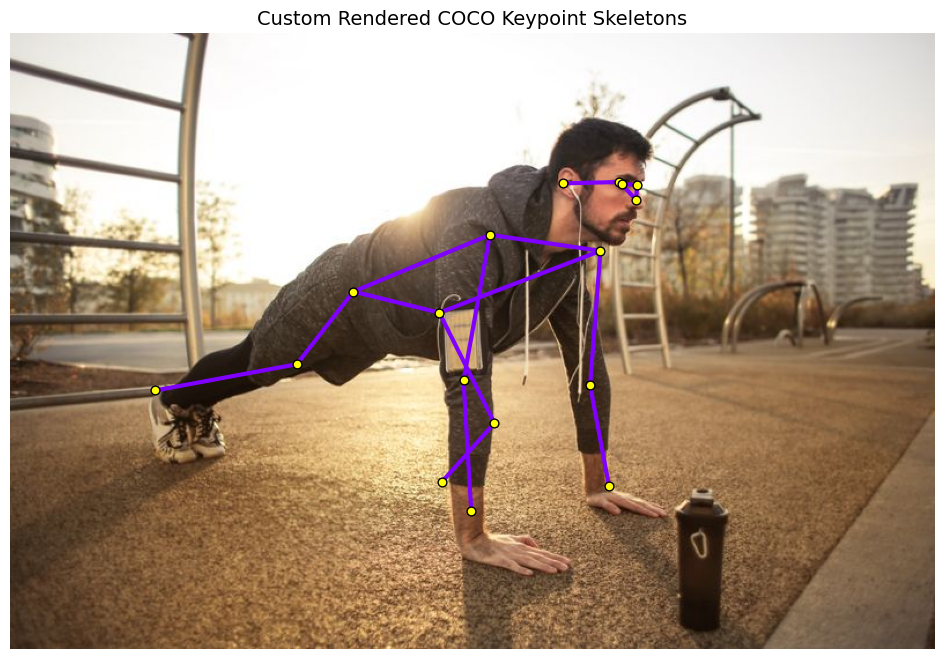

In [3]:
# Extract keypoints object from the first result
keypoints_obj = results[0].keypoints

# Extract coordinate tensors
xy_coords = keypoints_obj.xy.cpu().numpy()  # Shape: [N_persons, 17, 2]
conf_scores = keypoints_obj.conf.cpu().numpy() if keypoints_obj.conf is not None else None

print(f"Detected persons count: {len(xy_coords)}")
print(f"Keypoints array shape: {xy_coords.shape}")

# Define skeleton links connecting landmark pairs
SKELETON_CONNECTIONS = [
    (0, 1), (0, 2), (1, 3), (2, 4),         # Facial landmarks
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), # Upper body arms
    (5, 11), (6, 12), (11, 12),              # Main torso
    (11, 13), (13, 15), (12, 14), (14, 16)   # Lower body legs
]

# Custom rendering with Matplotlib
img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)

# Use a distinct color palette for each detected person
colors = plt.cm.rainbow(np.linspace(0, 1, len(xy_coords)))

for person_idx, (kpts, color) in enumerate(zip(xy_coords, colors)):
    # Draw limb lines
    for p1_idx, p2_idx in SKELETON_CONNECTIONS:
        pt1, pt2 = kpts[p1_idx], kpts[p2_idx]
        if pt1[0] > 0 and pt1[1] > 0 and pt2[0] > 0 and pt2[1] > 0:
            plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color=color, linewidth=3)

    # Draw joint points
    for pt in kpts:
        if pt[0] > 0 and pt[1] > 0:
            plt.scatter(pt[0], pt[1], color='yellow', edgecolor='black', s=40, zorder=4)

plt.title("Custom Rendered COCO Keypoint Skeletons", fontsize=14)
plt.axis("off")
plt.show()

## 5. Multi-Object Tracking (MOT) with ByteTRACK

In video analytics, detecting objects frame-by-frame is not enough. We need to assign a persistent **Track ID** (e.g. Person #1, Person #2) so that as objects move across frames, their identity remains consistent.

### How ByteTRACK Works
1. **Kalman Filtering:** Predicts the next bounding box position based on velocity and direction.
2. **IoU Matching:** Associates bounding boxes in frame $t+1$ with tracks in frame $t$.
3. **Low-Confidence Recovery:** Unlike traditional trackers that discard low-score detections, ByteTRACK retains low-confidence detections to recover occluded objects.


video 1/1 (frame 1/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 2/596) /content/sample_video.mp4: 384x640 (no detections), 6.6ms
video 1/1 (frame 3/596) /content/sample_video.mp4: 384x640 (no detections), 6.0ms
video 1/1 (frame 4/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 5/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 6/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 7/596) /content/sample_video.mp4: 384x640 (no detections), 5.7ms
video 1/1 (frame 8/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 9/596) /content/sample_video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 10/596) /content/sample_video.mp4: 384x640 (no detections), 6.0ms
video 1/1 (frame 11/596) /content/sample_video.mp4: 384x640 (no detections), 6.1ms
video 1/1 (frame 12/596) /content/sample_video.mp4: 384x640 (no detections), 5.7ms
video 1/1 (f

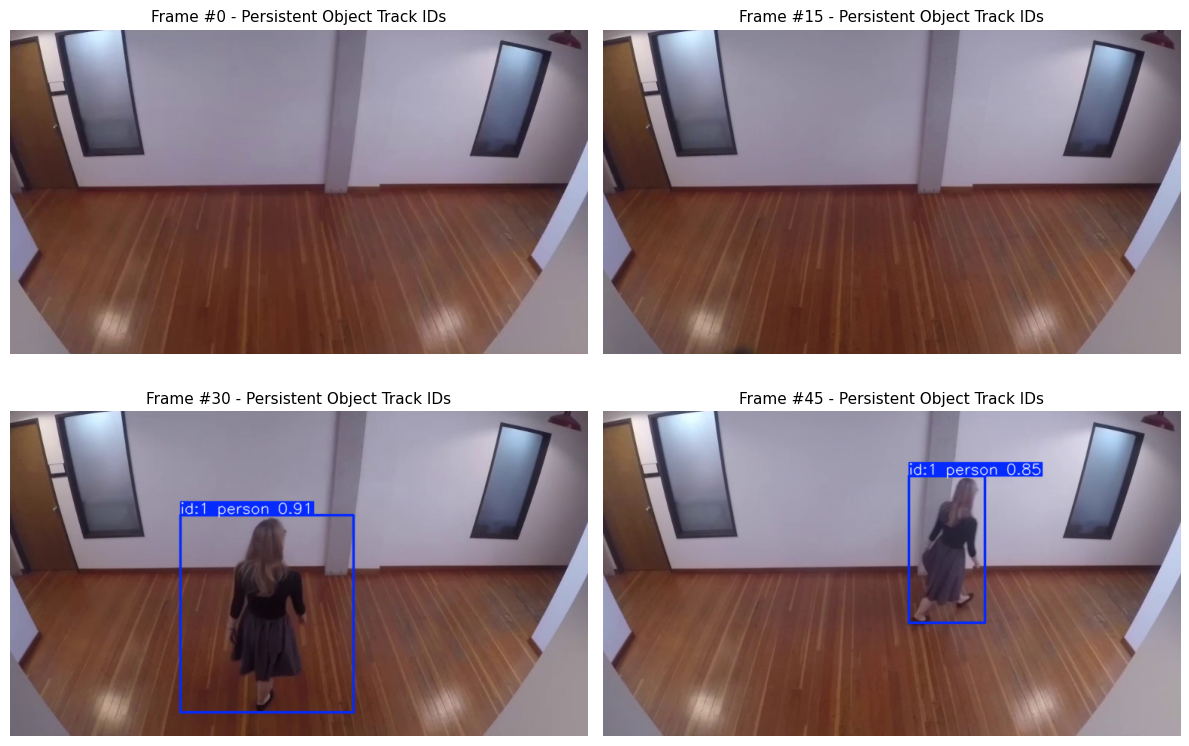

In [10]:
# Download a sample video clip (Intel IoT sample video repo)
video_url = "https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/people-detection.mp4"
video_path = "sample_video.mp4"

response = requests.get(video_url, stream=True)
response.raise_for_status()
with open(video_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

# Load standard object detection model for tracking
tracker_model = YOLO('yolov8n.pt')

# Run tracking stream using ByteTRACK algorithm
results_generator = tracker_model.track(
    source=video_path,
    tracker="bytetrack.yaml",
    stream=True,
    conf=0.3
)

# Extract and sample 4 distinct frames across the video timeline
sampled_frames = []
for frame_idx, r in enumerate(results_generator):
    if frame_idx % 15 == 0:  # Sample every 15th frame
        annotated_bgr = r.plot()
        sampled_frames.append((frame_idx, cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)))
    if len(sampled_frames) >= 4:
        break

# Display multi-frame tracking sequence
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (f_num, frame_rgb) in enumerate(sampled_frames):
    axes[idx].imshow(frame_rgb)
    axes[idx].set_title(f"Frame #{f_num} - Persistent Object Track IDs", fontsize=11)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 6. Summary & Computer Vision Task Comparison

Let's review the progression of computer vision tasks covered across our notebooks:

| Computer Vision Task | Output Representation | Primary Use Case |
| :--- | :--- | :--- |
| **Classification** | Single Class Label | Category recognition (e.g. "Dog") |
| **Object Detection** | Bounding Box $[x, y, w, h]$ | Multi-object localization |
| **Semantic / Instance Segmentation** | Pixel-level Mask | Exact boundary mapping (U-Net, SAM) |
| **Pose Estimation** | Keypoint Landmarks $[x, y, c]$ | Ergonomics, sports analytics, gesture tracking |
| **Multi-Object Tracking** | Bounding Box + Persistent ID | Traffic monitoring, surveillance, video analytics |

### 💡 Practical Takeaways
* **Real-time Performance:** YOLOv8-pose runs at over 100 FPS on GPU hardware, making it suitable for edge deployment.
* **Tracking Selection:** `bytetrack.yaml` works best for fast, IoU-based tracking with minimal compute overhead, while `botsort.yaml` adds camera motion compensation for moving cameras.